<a href="https://colab.research.google.com/github/jeevanshibatra27-create/part-2-cnn-computer-vision/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip /content/images.zip

Archive:  /content/images.zip.zip
   creating: images/
  inflating: images/.DS_Store        
   creating: images/dent/
  inflating: images/dent/dent_001.png  
  inflating: images/dent/dent_002.png  
  inflating: images/dent/dent_003.png  
  inflating: images/dent/dent_004.png  
  inflating: images/dent/dent_005.png  
  inflating: images/dent/dent_006.png  
  inflating: images/dent/dent_007.png  
  inflating: images/dent/dent_008.png  
  inflating: images/dent/dent_009.png  
  inflating: images/dent/dent_010.png  
  inflating: images/dent/dent_011.png  
  inflating: images/dent/dent_012.png  
  inflating: images/dent/dent_013.png  
  inflating: images/dent/dent_014.png  
  inflating: images/dent/dent_015.png  
  inflating: images/dent/dent_016.png  
  inflating: images/dent/dent_017.png  
  inflating: images/dent/dent_018.png  
  inflating: images/dent/dent_019.png  
  inflating: images/dent/dent_020.png  
  inflating: images/dent/dent_021.png  
  inflating: images/dent/dent_022.png  
 

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/content/images"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(4, activation='softmax')

])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.2656 - loss: 2.2267 - val_accuracy: 0.2500 - val_loss: 1.3948
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 995ms/step - accuracy: 0.2891 - loss: 1.3866 - val_accuracy: 0.2500 - val_loss: 1.3748
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 929ms/step - accuracy: 0.2943 - loss: 1.3611 - val_accuracy: 0.3438 - val_loss: 1.3238
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 877ms/step - accuracy: 0.5156 - loss: 1.2717 - val_accuracy: 0.6250 - val_loss: 1.1892
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 986ms/step - accuracy: 0.6667 - loss: 1.0564 - val_accuracy: 0.5208 - val_loss: 1.1335
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6927 - loss: 0.9284 - val_accuracy: 0.5729 - val_loss: 0.9149
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7005 - loss: 0.7332 - val_accuracy: 0.7708 - val_loss: 0.7029
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7917 - loss: 0.5750 - val_accuracy: 0.7812

In [6]:
import matplotlib.pyplot as plt

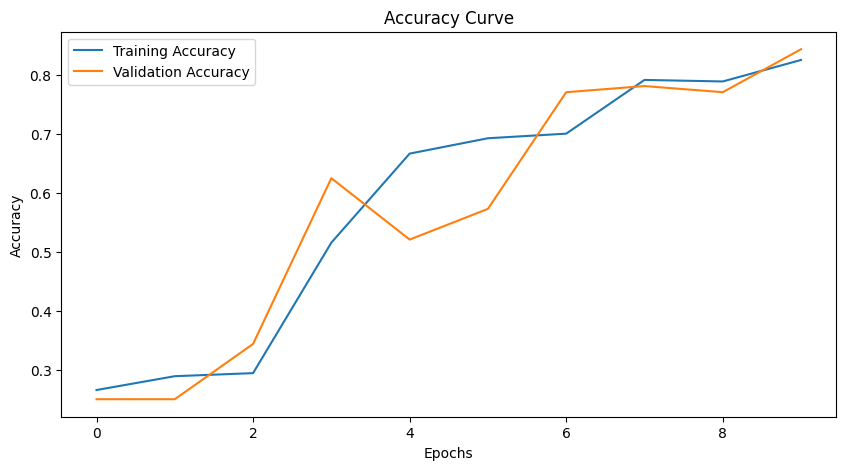

In [7]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()

plt.savefig("accuracy_loss_curves.png")

plt.show()

In [8]:
import os
os.makedirs("results", exist_ok=True)

In [9]:
import shutil

shutil.move(
    "accuracy_loss_curves.png",
    "results/accuracy_loss_curves.png"
)

print("File moved successfully!")

File moved successfully!


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 583ms/step


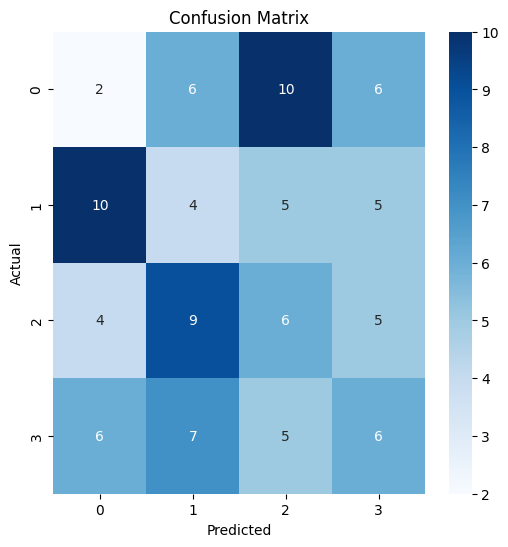

In [10]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predictions
y_pred = model.predict(val_data)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(6,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

In [11]:
shutil.move(
    "confusion_matrix.png",
    "results/confusion_matrix.png"
)

print("Confusion matrix saved!")

Confusion matrix saved!


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step


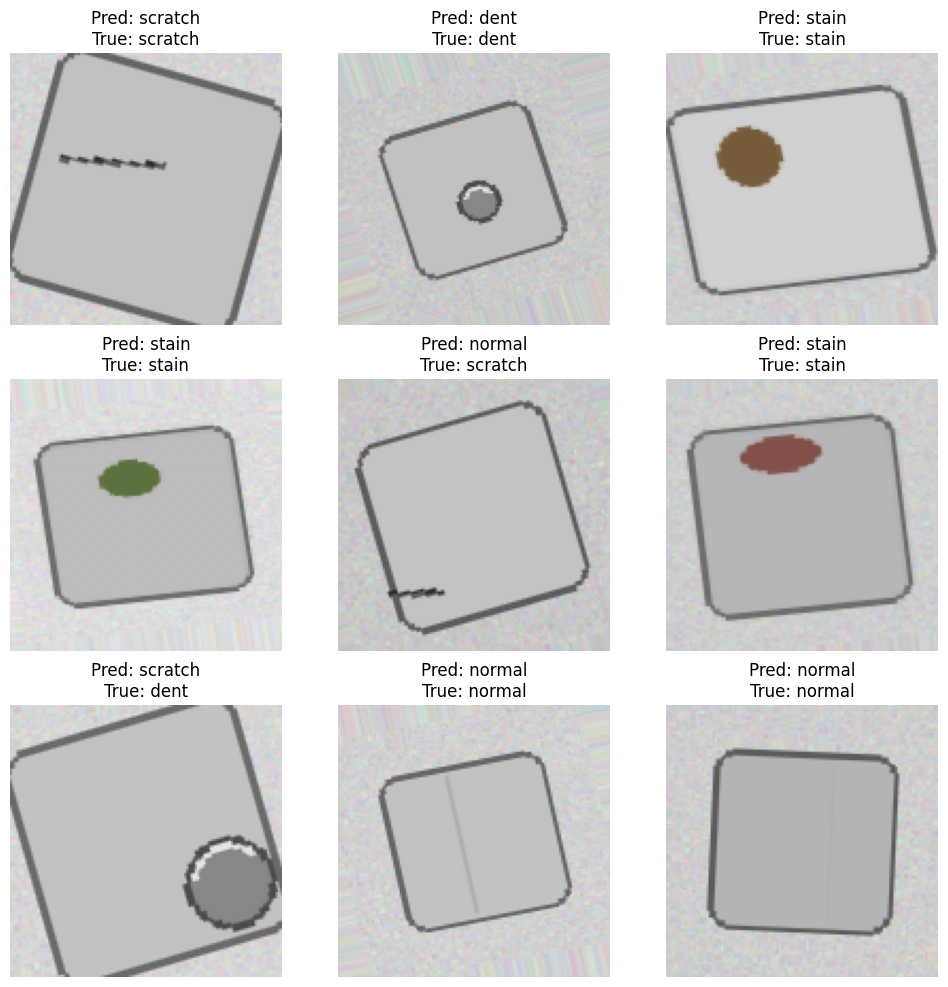

In [12]:
import random

class_names = list(train_data.class_indices.keys())

images, labels = next(val_data)

predictions = model.predict(images)

plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    predicted_class = class_names[np.argmax(predictions[i])]

    true_class = class_names[np.argmax(labels[i])]

    plt.title(f"Pred: {predicted_class}\nTrue: {true_class}")

    plt.axis("off")

plt.savefig("prediction_outputs.png")

plt.show()

In [14]:
os.makedirs("sample_predictions", exist_ok=True)

In [15]:
shutil.move(
    "prediction_outputs.png",
    "sample_predictions/prediction_outputs.png"
)

print("Prediction outputs saved!")

Prediction outputs saved!
